# 📊 Actividad 03 — EDA: Análisis Exploratorio de Datos
**Tesis:** Predicción de Producción de Limón | LSTM Multimodal  
**Fuente:** `data/02_interim/` → `data/04_reports/`

In [1]:
%matplotlib inline
import os, sys, json, re, warnings, unicodedata
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
with open('data/02_interim/pipeline_config.json','r',encoding='utf-8') as f:
    CFG = json.load(f)
DIRS=CFG['DIRS']; INTERIM=DIRS['interim']; REPORTS=DIRS['reports']; PROCESSED=DIRS['processed']
print(f"✅ Setup OK | CWD: {os.getcwd()}")

✅ Setup OK | CWD: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## 3.1 Carga de Datos

In [2]:

df_m = pd.read_csv(f"{INTERIM}/midagri_limon_raw.csv")
df_m['PRODUCCION(t)'] = pd.to_numeric(df_m['PRODUCCION(t)'], errors='coerce').fillna(0)
def norm(t):
    if not isinstance(t, str): return t
    t = t.strip().upper()
    for a,b in [('Á','A'),('É','E'),('Í','I'),('Ó','O'),('Ú','U')]: t=t.replace(a,b)
    t = ''.join(c for c in unicodedata.normalize('NFD',t) if unicodedata.category(c)!='Mn')
    return t
df_m['Dpto'] = df_m['Dpto'].apply(norm)
df_m['Prov'] = df_m['Prov'].apply(norm)
print(f"MIDAGRI: {len(df_m):,} registros | {df_m['Dpto'].nunique()} departamentos")
df_m.head()


MIDAGRI: 19,573 registros | 23 departamentos


,anho,mes,COD_UBIGEO,Dpto,Prov,Dist,dsc_Cultivo,PRODUCCION(t),COSECHA (ha),MTO_PRECCHAC (S/ x kg)
0,2021,1,10103,AMAZONAS,CHACHAPOYAS,BALSAS,LIMON,18.21,0.0,1.5
1,2021,1,10106,AMAZONAS,CHACHAPOYAS,CHUQUIBAMBA,LIMON,4.95,0.0,1.5
2,2021,1,10201,AMAZONAS,BAGUA,BAGUA,LIMON,15.00,0.0,1.5
3,2021,1,10202,AMAZONAS,BAGUA,ARAMANGO,LIMON,2.20,0.0,2.5
4,2021,1,10202,AMAZONAS,BAGUA,ARAMANGO,LIMON DULCE,6.00,0.0,1.3


## 3.2 Reporte Geográfico — 23 Departamentos Productores de Limón

In [3]:

geo = (df_m.groupby('Dpto')
       .agg(prod_total=('PRODUCCION(t)','sum'), n_prov=('Prov','nunique'), n_reg=('PRODUCCION(t)','count'))
       .sort_values('prod_total', ascending=False).reset_index())
total = geo['prod_total'].sum()
geo['pct'] = (geo['prod_total']/total*100).round(2)

# Tabla completa
print(f"{'DEPARTAMENTO':<25} {'PRODUCCIÓN (t)':>16} {'PROVINCIAS':>11} {'%':>7}")
print('-'*62)
for _, r in geo.iterrows():
    print(f"{r['Dpto']:<25} {r['prod_total']:>16,.2f} {int(r['n_prov']):>11} {r['pct']:>6.2f}%")
print('-'*62)
print(f"{'TOTAL':>25} {total:>16,.2f} {'':>11} {'100.00%':>7}")


DEPARTAMENTO                PRODUCCIÓN (t)  PROVINCIAS       %
--------------------------------------------------------------
PIURA                           844,788.80           7  54.45%
TUMBES                          262,721.15           3  16.93%
LAMBAYEQUE                      194,718.80           2  12.55%
UCAYALI                          57,912.15           4   3.73%
LORETO                           55,284.00           8   3.56%
JUNIN                            35,198.59           3   2.27%
AMAZONAS                         30,954.28           4   2.00%
SAN MARTIN                       25,201.56          10   1.62%
CUSCO                             8,456.00           1   0.55%
ICA                               7,008.53           5   0.45%
HUANUCO                           6,076.50           6   0.39%
ANCASH                            4,817.00           6   0.31%
CAJAMARCA                         4,738.85           8   0.31%
MADRE DE DIOS                     3,536.70           3 

## 3.3 Gráfico 1 — Producción por Departamento (Barra Horizontal)

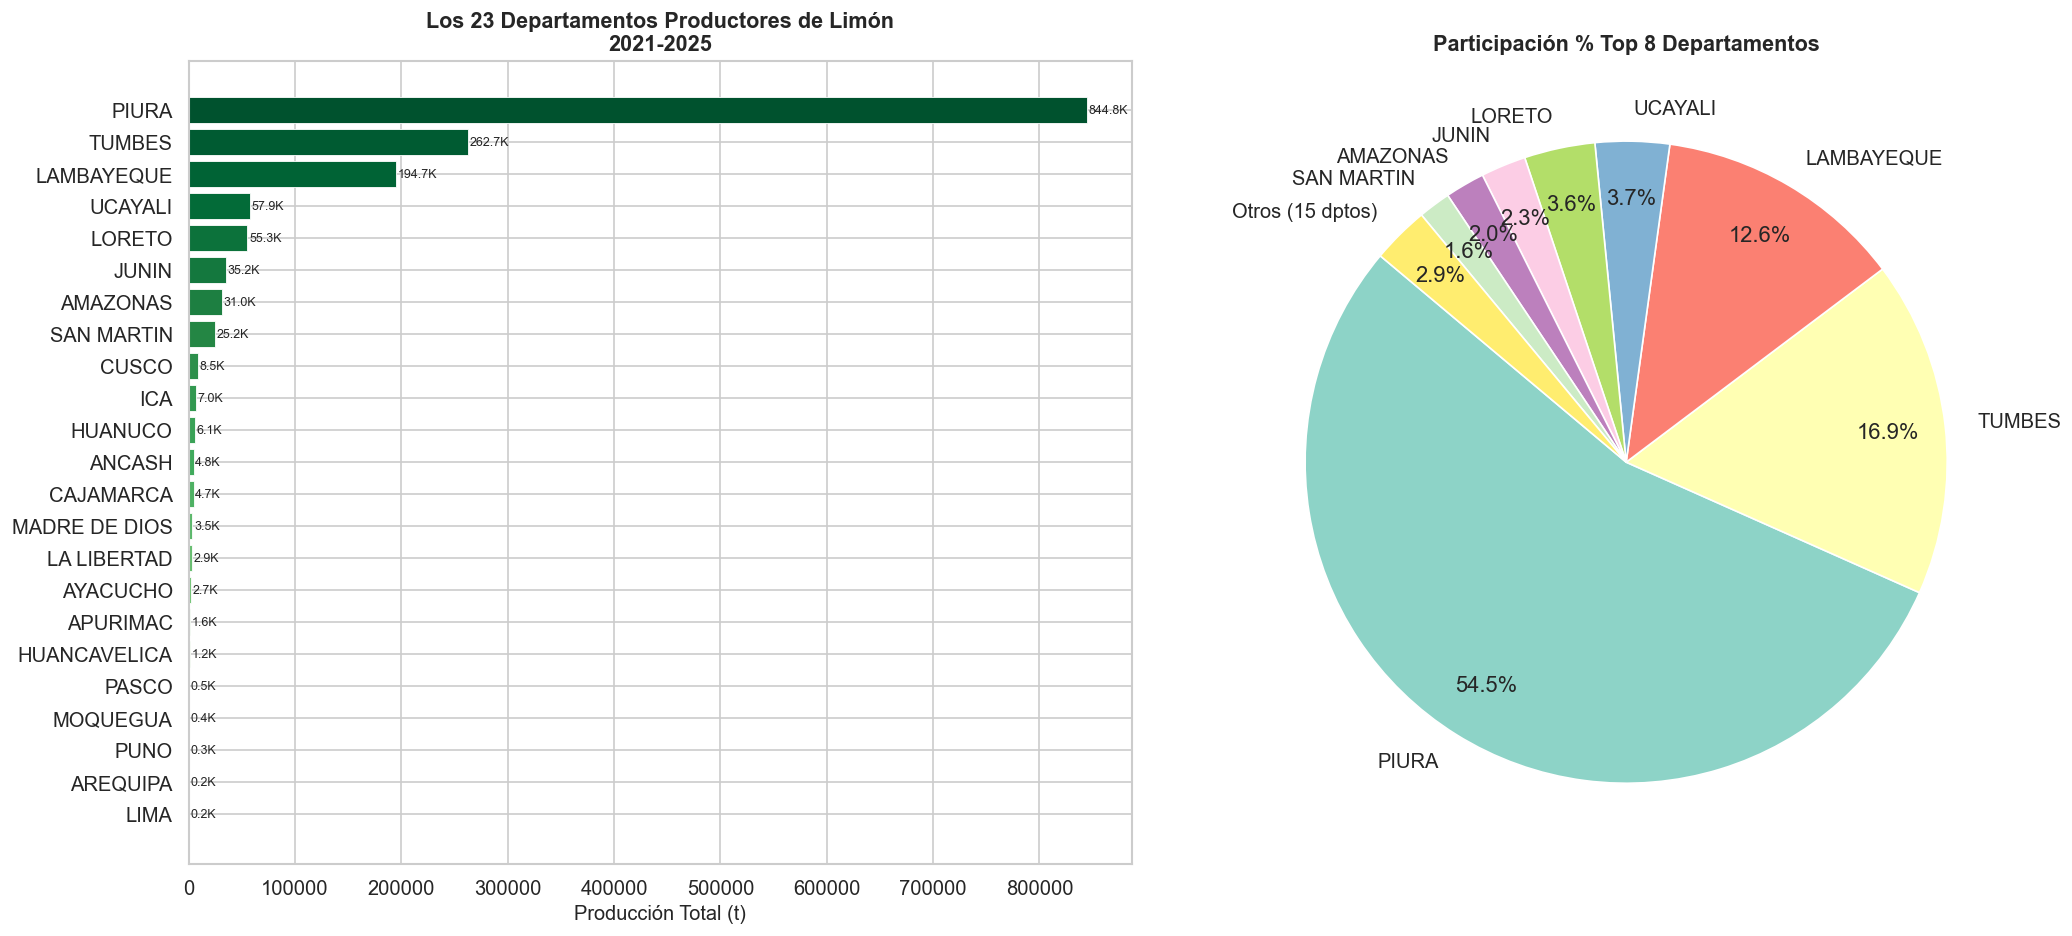

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
colors = plt.cm.YlGn(np.linspace(0.3, 0.95, len(geo)))[::-1]
axes[0].barh(geo['Dpto'], geo['prod_total'], color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Producción Total (t)', fontsize=12)
axes[0].set_title(f'Los {len(geo)} Departamentos Productores de Limón\n2021-2025', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
for i, (val, dpto) in enumerate(zip(geo['prod_total'], geo['Dpto'])):
    axes[0].text(val + total*0.001, i, f'{val/1000:.1f}K', va='center', fontsize=7.5)

# Participación % (top 8 + otros)
top = geo.head(8); otros = geo.iloc[8:]
pvals = list(top['prod_total']) + [otros['prod_total'].sum()]
plbls = [d[:14] for d in top['Dpto']] + [f'Otros ({len(otros)} dptos)']
wcols = plt.cm.Set3(np.linspace(0, 1, len(pvals)))
wedges, _, autotexts = axes[1].pie(pvals, labels=plbls, autopct='%1.1f%%',
    startangle=140, colors=wcols, pctdistance=0.82)
axes[1].set_title('Participación % Top 8 Departamentos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{REPORTS}/g01_prod_dpto.png", dpi=150, bbox_inches='tight')
plt.show()


## 3.4 Gráfico 2 — Serie Temporal de Producción Nacional

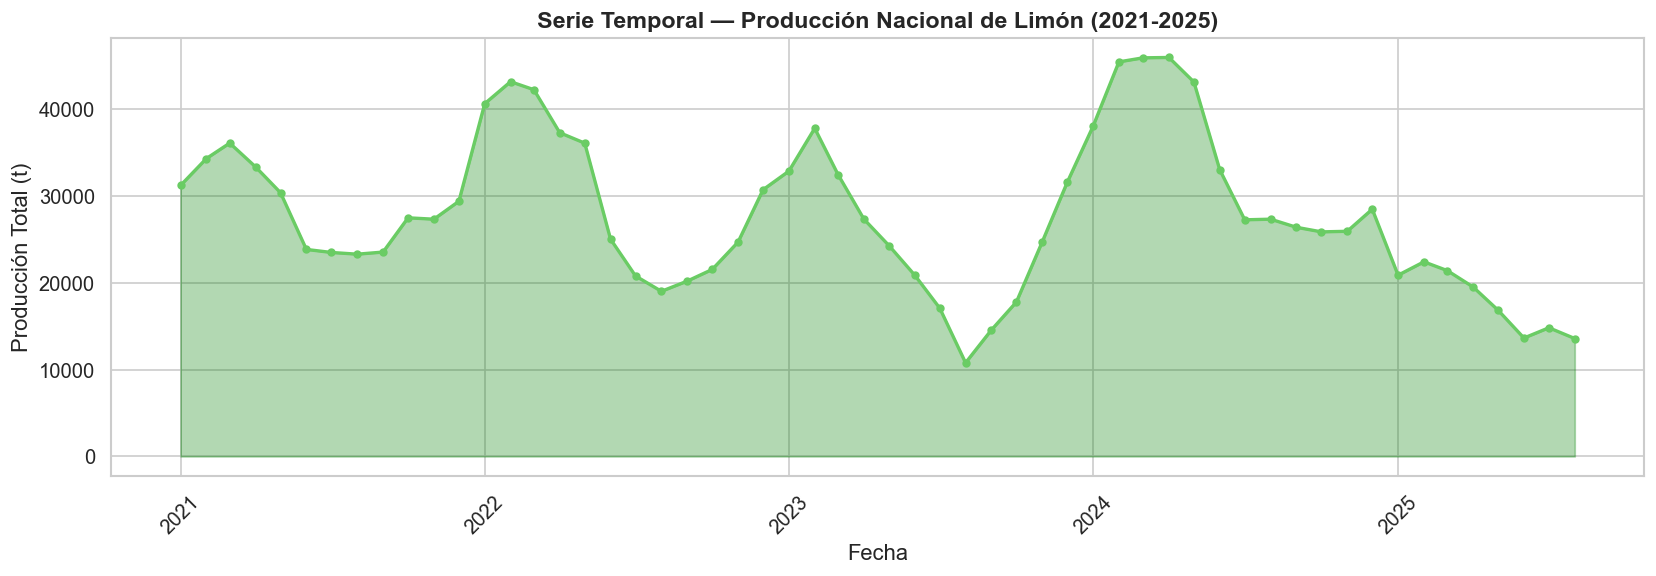

In [5]:

df_m['fecha_dt'] = pd.to_datetime(df_m['anho'].astype(str)+'-'+df_m['mes'].astype(str), format='%Y-%m')
ts = df_m.groupby('fecha_dt')['PRODUCCION(t)'].sum().reset_index()
fig, ax = plt.subplots(figsize=(14,5))
ax.fill_between(ts['fecha_dt'], ts['PRODUCCION(t)'], alpha=0.3, color='green')
ax.plot(ts['fecha_dt'], ts['PRODUCCION(t)'], 'g-o', markersize=4, linewidth=2)
ax.set_title('Serie Temporal — Producción Nacional de Limón (2021-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha'); ax.set_ylabel('Producción Total (t)')
ax.xaxis.set_tick_params(rotation=45)
plt.tight_layout(); plt.savefig(f"{REPORTS}/g02_serie_temporal.png", dpi=150, bbox_inches='tight')
plt.show()


## 3.5 INDECI — Top Fenómenos de Emergencia

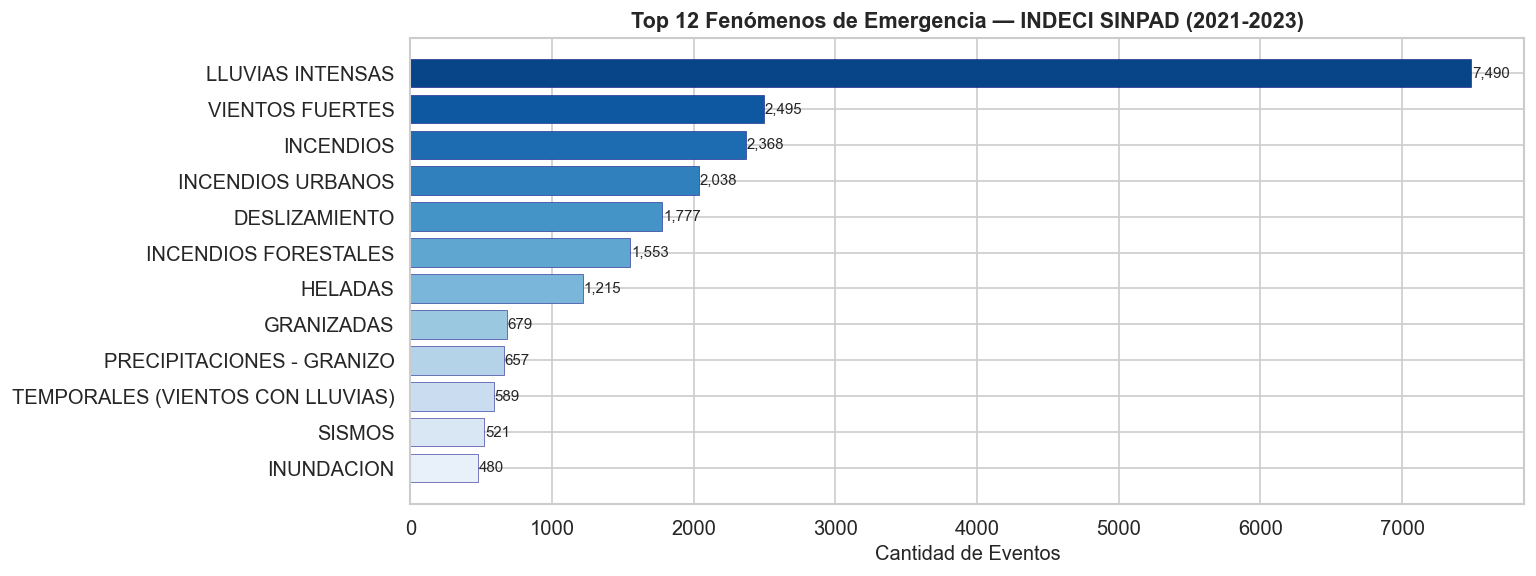

Total eventos: 25,025


In [6]:

df_ev = pd.read_csv(f"{INTERIM}/indeci_eventos_dbf.csv", low_memory=False)
df_ev['fenomeno'] = df_ev['fenomeno'].astype(str).str.upper().str.strip()
top_fen = df_ev['fenomeno'].value_counts().head(12)
fig, ax = plt.subplots(figsize=(13, 5))
colors2 = sns.color_palette("Blues_r", len(top_fen))
bars = ax.barh(top_fen.index, top_fen.values, color=colors2, edgecolor='navy', linewidth=0.3)
ax.set_xlabel('Cantidad de Eventos', fontsize=12)
ax.set_title('Top 12 Fenómenos de Emergencia — INDECI SINPAD (2021-2023)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)
plt.tight_layout(); plt.savefig(f"{REPORTS}/g03_fenomenos.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Total eventos: {len(df_ev):,}")


## 3.6 AGRARIA.PE — Frecuencia de Noticias

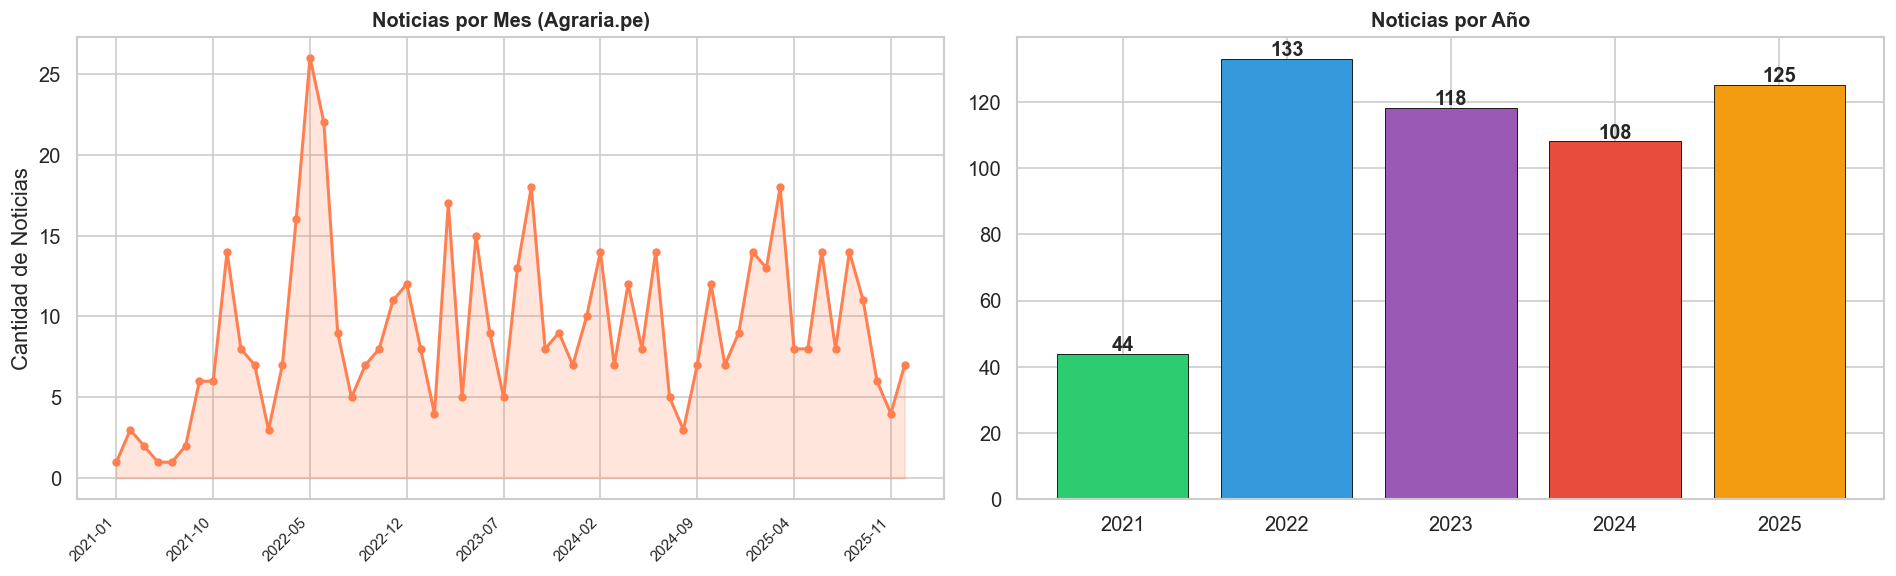

Total noticias: 528 | Rango: 2021-01-04 → 2025-12-22


In [7]:

df_n = pd.read_csv(f"{INTERIM}/agraria_noticias_raw.csv")
df_n['fecha'] = pd.to_datetime(df_n['fecha'], errors='coerce')
df_n['anho'] = df_n['fecha'].dt.year
df_n['mes_p'] = df_n['fecha'].dt.to_period('M').astype(str)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Mensual
freq_m = df_n.groupby('mes_p').size()
axes[0].plot(range(len(freq_m)), freq_m.values, 'coral', marker='o', markersize=4, linewidth=1.8)
axes[0].fill_between(range(len(freq_m)), freq_m.values, alpha=0.2, color='coral')
step = max(1, len(freq_m)//8)
axes[0].set_xticks(range(0, len(freq_m), step))
axes[0].set_xticklabels(freq_m.index[::step], rotation=45, ha='right', fontsize=9)
axes[0].set_title('Noticias por Mes (Agraria.pe)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad de Noticias')
# Anual
freq_a = df_n.groupby('anho').size()
bar_colors = ['#2ecc71','#3498db','#9b59b6','#e74c3c','#f39c12']
bars2 = axes[1].bar(freq_a.index.astype(str), freq_a.values, color=bar_colors[:len(freq_a)], edgecolor='black', linewidth=0.5)
axes[1].set_title('Noticias por Año', fontsize=12, fontweight='bold')
for b in bars2:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+1, str(int(b.get_height())),
                 ha='center', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig(f"{REPORTS}/g04_noticias.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Total noticias: {len(df_n)} | Rango: {df_n['fecha'].min().date()} → {df_n['fecha'].max().date()}")


## TODO: INTEGRACIÓN DATA NASA (COMPAÑERO)
```python
df_nasa = pd.read_csv(f"{INTERIM}/nasa_clima_raw.csv")
df_nasa['DATE'] = pd.to_datetime(df_nasa['DATE'])
# Temperatura mensual
df_nasa.set_index('DATE')['T2M'].resample('M').mean().plot(figsize=(14,4), title='T2M Mensual NASA POWER')
# Precipitación acumulada
df_nasa.set_index('DATE')['PRECTOTCORR'].resample('M').sum().plot(figsize=(14,4), color='blue', title='Precipitación Acumulada')
```

In [8]:

print("✅ [ACTIVIDAD 03] COMPLETADA — EDA con gráficos embebidos.")
print(f"  Departamentos analizados: {len(geo)}")
print(f"  Gráficos generados en {REPORTS}/")


✅ [ACTIVIDAD 03] COMPLETADA — EDA con gráficos embebidos.
  Departamentos analizados: 23
  Gráficos generados en data\04_reports/
